# Conformal Prediction in Mathematical Programming

In many optimization problems, uncertainty enters through unknown or noisy
functions, constraints, or parameters. Common examples include:
- uncertain demand or returns,
- black-box process models,
- learned constraints or objectives.

Standard approaches either:
- ignore uncertainty, or
- rely on parametric assumptions that are difficult to justify.

Conformal prediction provides a principled alternative:
it constructs **distribution-free uncertainty sets** with finite-sample
coverage guarantees.

These sets can be embedded directly into optimization models,
enabling **robust and tractable decision making under data-driven uncertainty**.

This notebook illustrates how conformal prediction can be used to construct
optimization-ready uncertainty sets, following the spirit of
*Conformal Mixed-Integer Constraint Learning with Feasibility Guarantees (2026) by Ovalle, Biegler, Grossmann, Laird, Dulce-Rubio*.


We reuse the same heteroscedastic regression setting as in the *01_conformal_tutorial.ipynb* notebook.
The goal is to learn:
- a predictor $ \widehat{h}(x) $,
- an uncertainty envelope $ \widehat{C}_\alpha(x) $,

which will later be embedded into a mathematical program.


## Library Setup

This notebook requires the following Python packages:
- `numpy`, `pandas`: data manipulation
- `matplotlib`: plotting
- `keras`: training the base regression and residual models
- `pyomo`: algebraic modeling language for defining the optimization model
- `omlt`: embedding trained neural networks into Pyomo optimization formulations

**NOTE:** This notebook requires a working MIP solver (e.g., Gurobi, CBC) to solve the mixed-integer optimization problem.


In [1]:
# data manipulation and plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# optimization
import pyomo.environ as pyo
from keras.layers import Dense, Input

# neural network training
from keras.models import Sequential

# OMLT: embedding neural networks in optimization
from omlt import OmltBlock
from omlt.io.keras import keras_reader
from omlt.neuralnet import ReluBigMFormulation

2026-05-12 20:30:39.619044: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 20:30:39.619826: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 20:30:39.623191: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 20:30:39.630095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778632239.641458   23144 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778632239.64

In [2]:
# Load data
df = pd.read_csv("../../data/heteroscedastic_data.csv")

X = df["x"].to_numpy()
y = df["y"].to_numpy()
n = len(X)

# Split indices
rng = np.random.default_rng(42)
idx = rng.permutation(n)

train_end = int(0.6 * n)
cal_end = int(0.8 * n)

train_idx = idx[:train_end]
cal_idx = idx[train_end:cal_end]
test_idx = idx[cal_end:]

We first train a regression model $ \widehat{h}(x) $.
The specific choice of model is immaterial: conformal prediction
will later provide uncertainty quantification in a model-agnostic way.


In [3]:
# Mean predictor
regr = Sequential()
regr.add(Input(shape=(1,)))
regr.add(Dense(30, activation="relu"))
regr.add(Dense(30, activation="relu"))
regr.add(Dense(30, activation="relu"))
regr.add(Dense(1))

regr.compile(optimizer="adam", loss="mean_squared_error")

regr.fit(
    X[train_idx],
    y[train_idx],
    epochs=1000,
    batch_size=64,
    verbose=0,
)

E0000 00:00:1778632242.877983   23144 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778632242.880121   23144 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


To obtain **input-dependent uncertainty sets**, we learn a residual scale model
$ \widehat{u}(x) $ from the training data.

This enables locally adaptive uncertainty sets, which are crucial for
efficient optimization.


In [4]:
# Training residuals
y_train_pred = regr.predict(X[train_idx].reshape(-1, 1), verbose=0).flatten()
train_residuals = np.abs(y[train_idx] - y_train_pred)

# Residual scale model
res_model = Sequential()
res_model.add(Input(shape=(1,)))
res_model.add(Dense(30, activation="relu"))
res_model.add(Dense(30, activation="relu"))
res_model.add(Dense(1))

res_model.compile(optimizer="adam", loss="mean_squared_error")

res_model.fit(
    X[train_idx],
    train_residuals,
    epochs=1000,
    batch_size=64,
    verbose=0,
)

Using the calibration set, we compute normalized conformity scores

$$
s_i = \frac{|y_i - \widehat{h}(x_i)|}{\widehat{u}(x_i)},
$$

and select a conformal quantile to guarantee coverage.


In [5]:
alpha = 0.1

# Calibration predictions
y_cal_pred = regr.predict(X[cal_idx].reshape(-1, 1), verbose=0).flatten()
u_cal_pred = res_model.predict(X[cal_idx].reshape(-1, 1), verbose=0).flatten()

eps = 1e-8
u_cal_pred = np.maximum(u_cal_pred, eps)

# Normalized scores
s = np.abs(y[cal_idx] - y_cal_pred) / u_cal_pred

# Conformal quantile
n_cal = len(s)
q = np.quantile(
    s,
    np.ceil((n_cal + 1) * (1 - alpha)) / n_cal,
)

print(f"Conformal quantile: {q:.3f}")

Conformal quantile: 2.381


The resulting conformal prediction set is

$$
\widehat{C}_\alpha(x)
=
\left[
\widehat{h}(x) \pm \widehat{q}_{1-\alpha} \widehat{u}(x)
\right].
$$

Crucially, this set:
- is distribution-free,
- has finite-sample coverage,
- is explicitly parameterized by learned functions,
- can be embedded into optimization constraints.


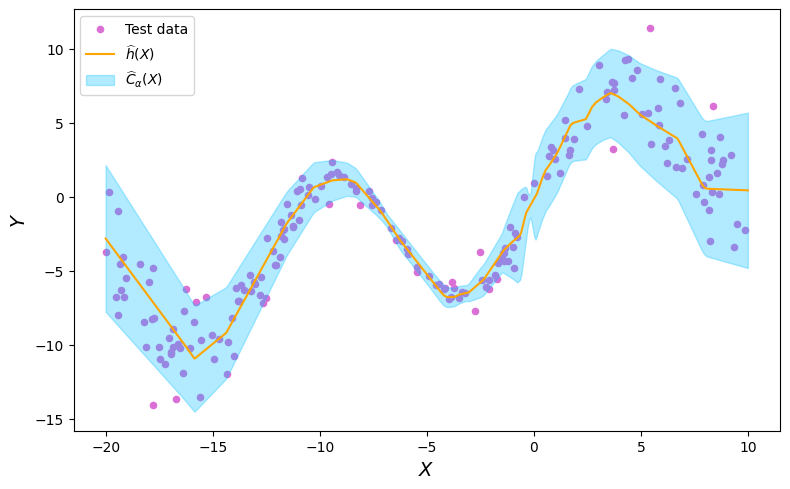

In [6]:
# Prediction grid
X_span = np.linspace(X.min(), X.max(), 500)
y_span = regr.predict(X_span.reshape(-1, 1), verbose=0).flatten()
u_span = res_model.predict(X_span.reshape(-1, 1), verbose=0).flatten()

lower_span = y_span - q * u_span
upper_span = y_span + q * u_span

plt.figure(figsize=(8, 5))

plt.scatter(
    X[test_idx],
    y[test_idx],
    color="orchid",
    label="Test data",
    s=20,
)

plt.plot(
    X_span,
    y_span,
    color="orange",
    label=r"$\widehat{h}(X)$",
)

plt.fill_between(
    X_span,
    lower_span,
    upper_span,
    color="deepskyblue",
    alpha=0.3,
    label=r"$\widehat{C}_\alpha(X)$",
)

plt.xlabel(r"$X$", fontsize=14)
plt.ylabel(r"$Y$", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

At this point, we have constructed a **learned uncertainty set**
of the form

$$
Y \in \widehat{h}(x) \pm \widehat{q}_{1-\alpha} \widehat{u}(x).
$$

In the next section, we will show how sets of this form can be:
- embedded into linear constraints,
- used to produce decisions with formal probabilistic uncertainty quantification.

This is the key connection between conformal prediction
and optimization under uncertainty.

##  Motivation: Optimization Under Uncertainty

Many optimization problems involve unknown system responses that must satisfy hard safety or performance requirements.

Let  
- $ x $ denote a controllable decision variable (e.g., a setpoint, design variable, or operating condition),
- $y = h(x) $ denote an outcome of interest defined by an unknown mapping function $h$.

We are interested in solving problems of the form
$$
\min_{x \in \mathcal{X}} c(x),
$$
subject to **feasibility constraints**, such as
$$
h(x) \ge y_{\min},
\qquad
h(x) \le y_{\max}.
$$

Such constraints arise naturally in safety-critical and reliability-driven applications.

## Learning a Predictive Model

We model the conditional response using a regression function
$$
\widehat{h}(x) \approx \mathbb{E}[Y(x) \mid x],
$$
together with a learned, input-dependent residual scale
$$
\widehat{u}(x) \approx |Y(x) - \widehat{h}(x)|.
$$

The pair $ (\widehat{h}, \widehat{u}) $ is trained using standard supervised learning techniques and calibrated via conformal prediction.


## Conformal Predictive Sets

Using a calibration dataset, we construct a conformal predictive set
$$
\widehat{\mathcal{C}}_\alpha(x)
=
\left[
\widehat{h}(x) - q_{1-\alpha}\,\widehat{u}(x),
\;
\widehat{h}(x) + q_{1-\alpha}\,\widehat{u}(x)
\right],
$$
where $ q_{1-\alpha} $ is a quantile of normalized calibration scores.

This set satisfies the **finite-sample coverage guarantee**
$$
\mathbb{P}\big( Y(x) \in \widehat{\mathcal{C}}_\alpha(x) \big) \ge 1 - \alpha,
$$
without any distributional assumptions.

## Optimization with Conformal Constraints

We now enforce safety by requiring **all realizations within the predictive set** to satisfy the constraints.

This leads to the optimization problem
$$
\begin{array}{ll}
\displaystyle \min_{x \in \mathcal{X}} & c(x) \\[0.5em]
\text{s.t.} 
& \inf_{y \in \widehat{\mathcal{C}}_\alpha(x)} y \;\ge\; y_{\min}, \\[0.25em]
& \sup_{y \in \widehat{\mathcal{C}}_\alpha(x)} y \;\le\; y_{\max}.
\end{array}
$$

Because $ \widehat{\mathcal{C}}_\alpha(x) $ is an interval, these constraints admit a deterministic reformulation:
$$
\widehat{h}(x) - \widehat{q}_{1-\alpha}\,\widehat{u}(x) \;\ge\; y_{\min},
$$
$$
\widehat{h}(x) + \widehat{q}_{1-\alpha}\,\widehat{u}(x) \;\le\; y_{\max}.
$$

--- 
## Pyomo and OMLT: Optimization with Learned Models

Before proceeding, we briefly introduce the tools used to embed learned models into optimization problems.

### Pyomo

**Pyomo** is an open-source, Python-based modeling language for mathematical optimization. It allows users to formulate optimization problems using high-level algebraic syntax that closely mirrors mathematical notation, making it well suited for expressing complex models in a clear and structured way. Pyomo supports a wide range of problem classes, including linear, nonlinear, mixed-integer, and disjunctive optimization, and it provides a solver-agnostic interface that can be connected to both open-source and commercial solvers. In this tutorial, Pyomo serves as the **host optimization framework**, within which decision variables, objectives, and conformal safety constraints are defined and enforced.

### OMLT (Optimization and Machine Learning Toolkit)

**OMLT** is a software library designed to integrate trained machine learning models into optimization formulations. It provides tools to parse models trained in common machine learning frameworks, such as Keras or PyTorch (via ONNX), and to translate them into exact or approximate algebraic reformulations that can be embedded as constraints in an optimization problem. OMLT supports multiple formulations for ReLU neural networks, including Big-M and complementarity-based approaches. In this tutorial, OMLT is used to embed the neural networks $ \widehat{h}(x) $ and $ \widehat{u}(x) $ directly into a Pyomo model, enabling neural network evaluations to be represented as deterministic constraints and allowing optimization to be performed over the inputs of learned models rather than treating them as black-box predictors.

### Why This Matters

Together, Pyomo and OMLT enable **end-to-end decision making under uncertainty**. Predictions are learned from data, uncertainty is quantified using conformal prediction, and decisions are computed by solving a mathematical program with finite-sample, distribution-free guarantees. This integration provides a principled foundation for data-driven optimization methods such as CMICL.


## Embedding Conformal Prediction into Optimization with OMLT

We now show how to **embed conformal prediction sets directly into a mathematical programming formulation**.

The key idea is simple:

1. Train two neural networks:
   - $ \widehat{h}(x) $: mean prediction
   - $ \widehat{u}(x) $: residual scale
2. Use conformal calibration to compute a scalar quantile $ \widehat{q}_{1-\alpha} $.
3. Enforce safety by requiring **all values in the predictive set** to satisfy the constraint.


In [7]:
# Input domain for the decision variable x
x_min, x_max = X.min(), X.max()
input_bounds = [(x_min, x_max)]

# Load Keras models into OMLT
net_h = keras_reader.load_keras_sequential(regr, None, input_bounds)

net_u = keras_reader.load_keras_sequential(res_model, None, input_bounds)

### Define the Optimization Model

We define:
- a decision variable $ x $,
- auxiliary variables for the network outputs $ \hat h(x) $ and $ \hat u(x) $.


In [8]:
model = pyo.ConcreteModel()

# Decision variable
model.x = pyo.Var(bounds=(x_min, x_max))

# Network outputs
model.h = pyo.Var()
model.u = pyo.Var(within=pyo.NonNegativeReals)

# Embed mean regressor h(x)

model.nn_h = OmltBlock()

formulation_h = ReluBigMFormulation(net_h)
model.nn_h.build_formulation(formulation_h)


@model.Constraint()
def connect_h_input(m):
    return m.x == m.nn_h.inputs[0]


@model.Constraint()
def connect_h_output(m):
    return m.h == m.nn_h.outputs[0]


# Embed residual regressor u(x)

model.nn_u = OmltBlock()

formulation_u = ReluBigMFormulation(net_u)
model.nn_u.build_formulation(formulation_u)


@model.Constraint()
def connect_u_input(m):
    return m.x == m.nn_u.inputs[0]


@model.Constraint()
def connect_u_output(m):
    return m.u == m.nn_u.outputs[0]

###  Conformal Safety Constraints

Let $ q_{1-\alpha} $ be the conformal quantile obtained from calibration.

The predictive set is
$$
\widehat{\mathcal{C}}_\alpha(x)
=
\left[
\widehat{h}(x) - q_{1-\alpha}\widehat{u}(x),
\;
\widehat{h}(x) + q_{1-\alpha}\widehat{u}(x)
\right].
$$

Requiring all values in this set to be feasible yields two deterministic constraints.


In [9]:
# Conformal parameters
y_min = -5
y_max = 5


@model.Constraint()
def lower_conformal(m):
    return m.h - q * m.u >= y_min


@model.Constraint()
def upper_conformal(m):
    return m.h + q * m.u <= y_max

In [10]:
model.obj = pyo.Objective(expr=model.x, sense=pyo.maximize)

# Solve
# The solver can be changed to any MIP solver (e.g., "gurobi", "cplex", "highs", "glpk").
solver = pyo.SolverFactory("cbc")
results = solver.solve(model, tee=True)

Welcome to the CBC MILP Solver 
Version: 2.10.10 
Build Date: Jun  7 2023 

command line - /home/dovallev/.idaes/bin/cbc -printingOptions all -import /tmp/tmpabbu1flg.pyomo.lp -stat=1 -solve -solu /tmp/tmpabbu1flg.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
 CoinLpIO::readLp(): Maximization problem reformulated as minimization
Coin0009I Switching back to maximization to get correct duals etc
Presolve 543 (-225) rows, 392 (-75) columns and 3903 (-301) elements
Statistics for presolved model
Original problem has 150 integers (150 of which binary)
Presolved problem has 149 integers (149 of which binary)
==== 391 zero objective 2 different
391 variables have objective of -0
1 variables have objective of 1
==== absolute objective values 2 different
391 variables have objective of 0
1 variables have objective of 1
==== for integers 149 zero objective 1 different
149 variables have objective of -0
==== for integers absolute objective values 1 differen

### Visualizing the Conformal Predictive Set and the Optimal Decision

We now visualize:
- the learned regression function $ \widehat{h}(x) $,
- the conformal predictive set $ \widehat{\mathcal{C}}_\alpha(x) $,
- the safety thresholds $ y_{\min}, y_{\max} $,
- and the optimal solution $ x^\star $ returned by the optimization model.

This figure provides a geometric interpretation of how the optimization problem selects a decision that is **robust with respect to the learned uncertainty set**.


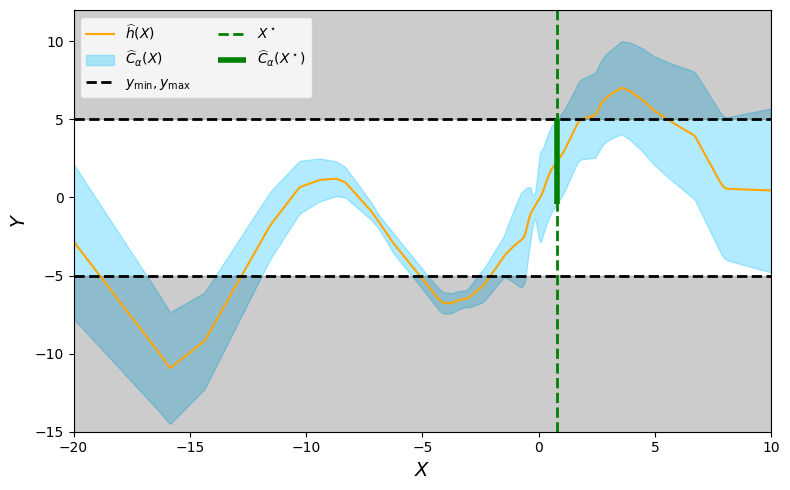

In [11]:
# Optimal solution from the optimization model
x_star = pyo.value(model.x)
h_star = pyo.value(model.h)
u_star = pyo.value(model.u)

# Prediction grid
X_span = np.linspace(X.min(), X.max(), 500)
y_span = regr.predict(X_span.reshape(-1, 1), verbose=0).flatten()
u_span = res_model.predict(X_span.reshape(-1, 1), verbose=0).flatten()

# Conformal predictive interval
lower_span = y_span - q * u_span
upper_span = y_span + q * u_span

plt.figure(figsize=(8, 5))


# Mean prediction
plt.plot(
    X_span,
    y_span,
    color="orange",
    label=r"$\widehat{h}(X)$",
)

# Conformal predictive set
plt.fill_between(
    X_span,
    lower_span,
    upper_span,
    color="deepskyblue",
    alpha=0.3,
    label=r"$\widehat{C}_\alpha(X)$",
)

# Unsafe regions (background shading)
plt.fill_between(
    X_span,
    y_span.min() - 5,
    y_min,
    color="black",
    alpha=0.2,
)

plt.fill_between(
    X_span,
    y_max,
    y_span.max() + 5,
    color="black",
    alpha=0.2,
)


# Safety thresholds
plt.axhline(
    y_min,
    color="black",
    linestyle="--",
    lw=2,
    label=r"$y_{\min}, y_{\max}$",
)

plt.axhline(
    y_max,
    color="black",
    linestyle="--",
    lw=2,
)

plt.axvline(x_star, color="green", lw=2, linestyle="--", label=r"$X^\star$")

# Predictive interval at x*
plt.vlines(
    x_star,
    h_star - q * u_star,
    h_star + q * u_star,
    color="green",
    lw=4,
    label=r"$\widehat{C}_\alpha(X^\star)$",
)

plt.xlabel(r"$X$", fontsize=14)
plt.ylabel(r"$Y$", fontsize=14)
plt.xlim(-20, 10)
plt.ylim(-15, 12)
plt.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

### Interpretation

The vertical line at $ x^\star $ corresponds to the **largest admissible value of the decision variable** that remains feasible under uncertainty.

In particular, $ x^\star $ is chosen such that the *entire conformal predictive interval*
$$
\widehat{\mathcal{C}}_\alpha(x^\star)
=
\left[
\widehat{h}(x^\star) - q_{1-\alpha}\widehat{u}(x^\star),
\;
\widehat{h}(x^\star) + q_{1-\alpha}\widehat{u}(x^\star)
\right]
$$
lies within the safe region $ [y_{\min}, y_{\max}] $.

Any larger value of $ x $ would cause part of the predictive set to cross a safety boundary, violating feasibility with respect to the learned uncertainty.  

Thus, the optimization problem selects the **maximum operating point that respects the safety bounds once uncertainty is taken into account**, rather than optimizing only for the mean prediction.


## Citation

If this notebook was useful to your work, please cite:

```bibtex
@article{ovalle2026conformal,
  title={Conformal Mixed-Integer Constraint Learning with Feasibility Guarantees},
  author={Ovalle, Daniel and Biegler, Lorenz and Grossmann, Ignacio and Laird, Carl and Dulce Rubio, Mateo},
  journal={Advances in Neural Information Processing Systems},
  volume={38},
  pages={80387--80423},
  year={2026}
}
```
